In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/india_housing_prices.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Shape: (250000, 23)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-n

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
# Statistical summary of numeric columns
print(df.describe())

print("\n--- Unique values in categorical columns ---")
categorical_cols = ['State', 'City', 'Property_Type', 'Furnished_Status', 
                     'Public_Transport_Accessibility', 'Parking_Space', 
                     'Security', 'Facing', 'Owner_Type', 'Availability_Status']

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique())

                  ID            BHK   Size_in_SqFt  Price_in_Lakhs  \
count  250000.000000  250000.000000  250000.000000   250000.000000   
mean   125000.500000       2.999396    2749.813216      254.586854   
std     72168.927986       1.415521    1300.606954      141.349921   
min         1.000000       1.000000     500.000000       10.000000   
25%     62500.750000       2.000000    1623.000000      132.550000   
50%    125000.500000       3.000000    2747.000000      253.870000   
75%    187500.250000       4.000000    3874.000000      376.880000   
max    250000.000000       5.000000    5000.000000      500.000000   

       Price_per_SqFt     Year_Built       Floor_No   Total_Floors  \
count   250000.000000  250000.000000  250000.000000  250000.000000   
mean         0.130597    2006.520012      14.966800      15.503004   
std          0.130747       9.808575       8.948047       8.671618   
min          0.000000    1990.000000       0.000000       1.000000   
25%          0.0500

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

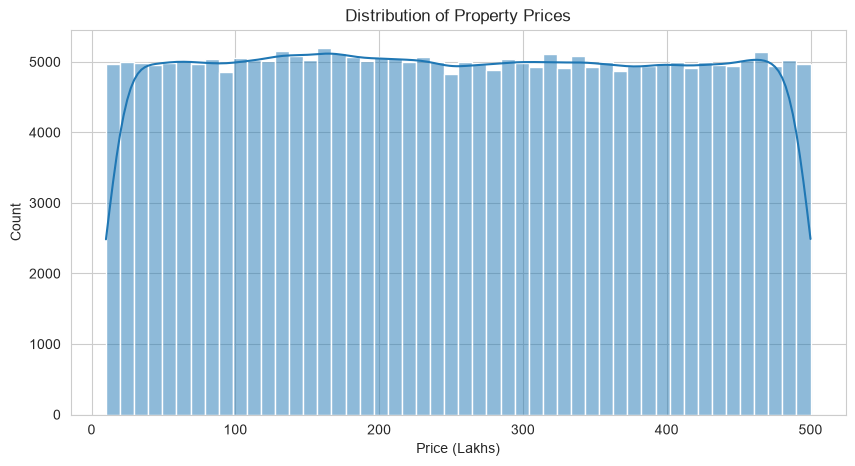

In [6]:
# 1. Distribution of property prices
plt.figure(figsize=(10,5))
sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True)
plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.show()

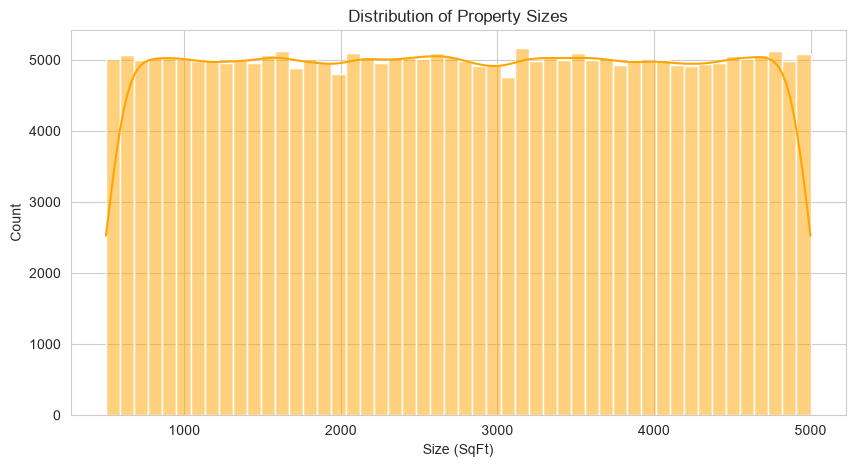

In [7]:
# 2. Distribution of property sizes
plt.figure(figsize=(10,5))
sns.histplot(df['Size_in_SqFt'], bins=50, kde=True, color='orange')
plt.title("Distribution of Property Sizes")
plt.xlabel("Size (SqFt)")
plt.show()

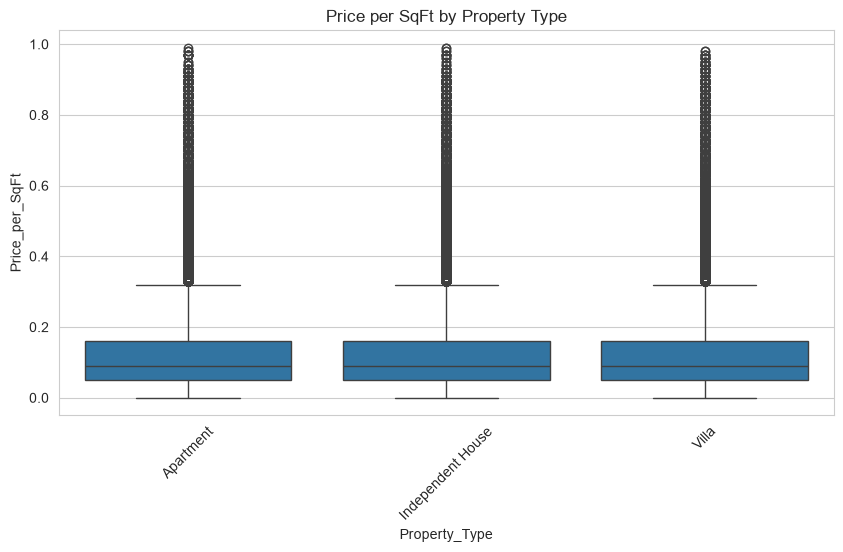

In [8]:
# 3. Price per sqft by property type
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Property_Type', y='Price_per_SqFt')
plt.title("Price per SqFt by Property Type")
plt.xticks(rotation=45)
plt.show()

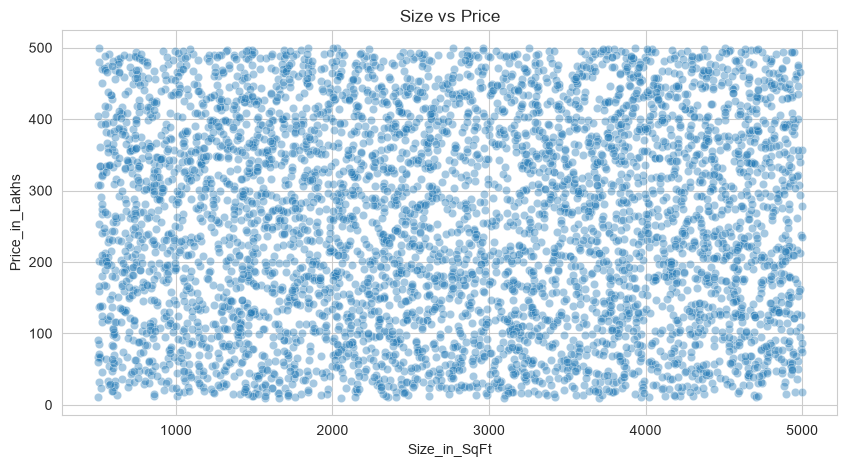

In [9]:
# 4. Size vs Price relationship
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.sample(5000), x='Size_in_SqFt', y='Price_in_Lakhs', alpha=0.4)
plt.title("Size vs Price")
plt.show()

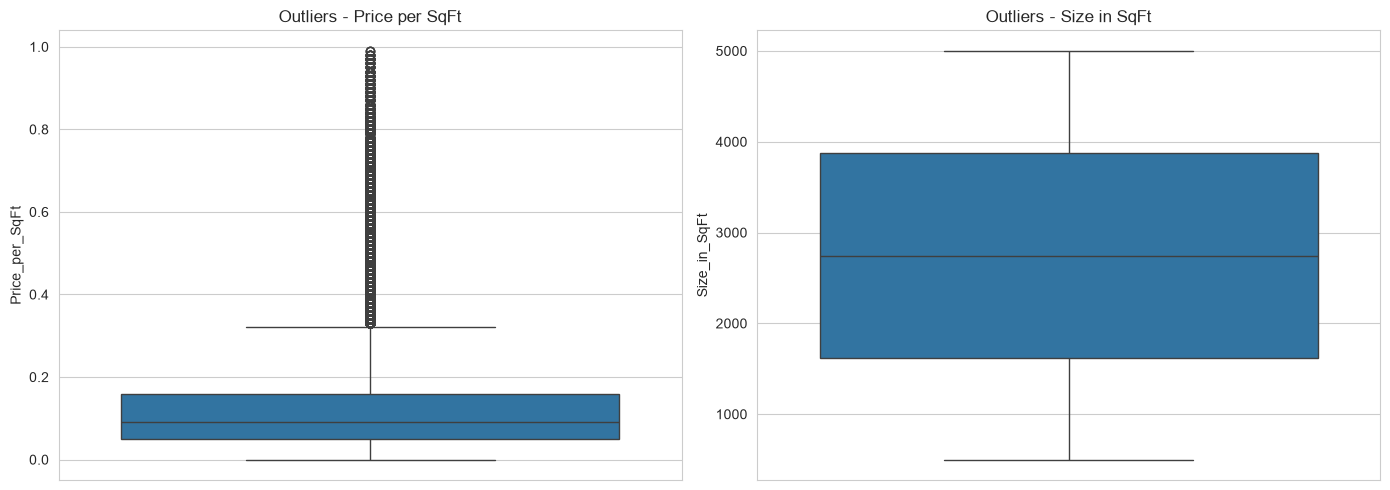

In [10]:
# 5. Outliers in price per sqft and size (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(y=df['Price_per_SqFt'], ax=axes[0])
axes[0].set_title("Outliers - Price per SqFt")
sns.boxplot(y=df['Size_in_SqFt'], ax=axes[1])
axes[1].set_title("Outliers - Size in SqFt")
plt.tight_layout()
plt.show()

C:\Users\suppo\AppData\Local\Temp\ipykernel_14960\3794430674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.values, y=state_avg.index, palette='viridis')


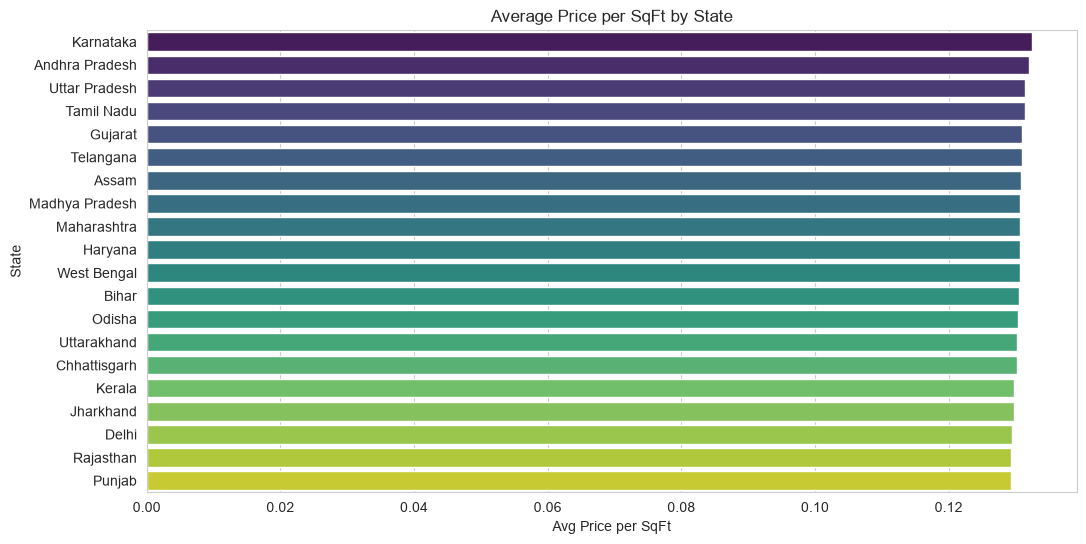

In [11]:
# 6. Average price per sqft by state
plt.figure(figsize=(12,6))
state_avg = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)
sns.barplot(x=state_avg.values, y=state_avg.index, palette='viridis')
plt.title("Average Price per SqFt by State")
plt.xlabel("Avg Price per SqFt")
plt.show()

C:\Users\suppo\AppData\Local\Temp\ipykernel_14960\1663510198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.values, y=city_avg.index, palette='mako')


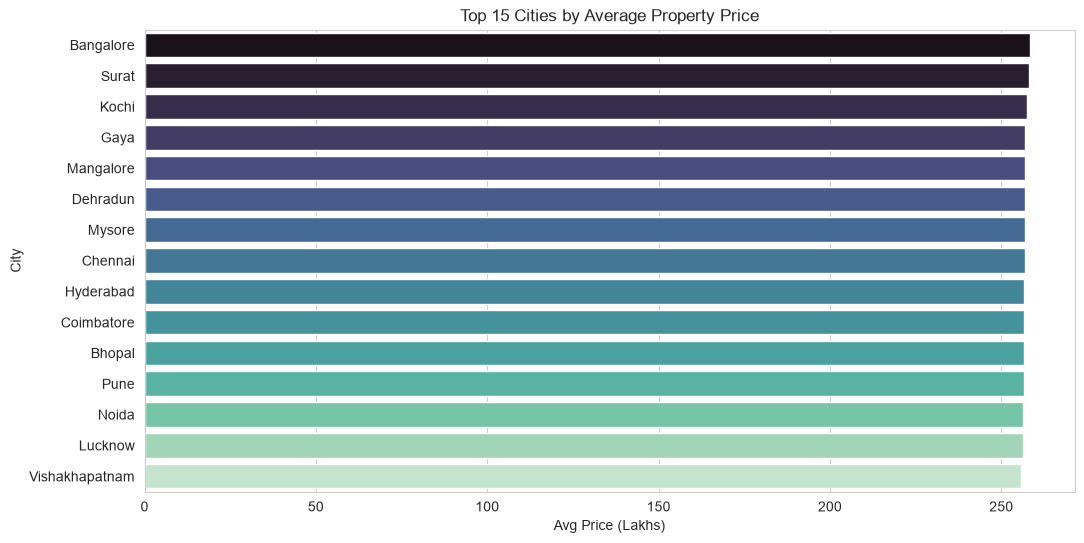

In [12]:
# 7. Average property price by city
plt.figure(figsize=(12,6))
city_avg = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=city_avg.values, y=city_avg.index, palette='mako')
plt.title("Top 15 Cities by Average Property Price")
plt.xlabel("Avg Price (Lakhs)")
plt.show()

C:\Users\suppo\AppData\Local\Temp\ipykernel_14960\2736437141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=locality_age.values, y=locality_age.index, palette='crest')


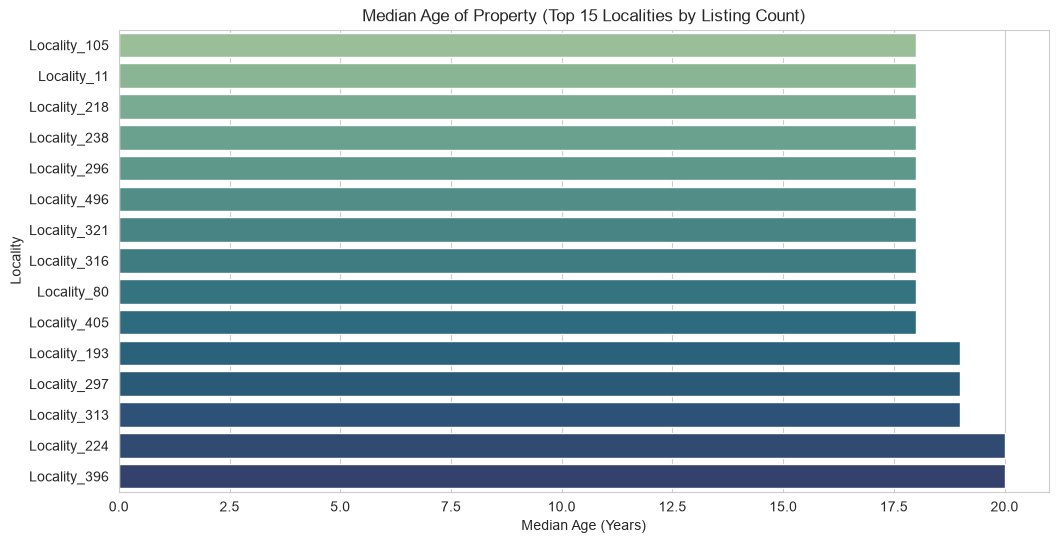

In [13]:
# 8. Median age of properties by locality (top 15 localities by count)
top_localities = df['Locality'].value_counts().head(15).index
locality_age = df[df['Locality'].isin(top_localities)].groupby('Locality')['Age_of_Property'].median().sort_values()
plt.figure(figsize=(12,6))
sns.barplot(x=locality_age.values, y=locality_age.index, palette='crest')
plt.title("Median Age of Property (Top 15 Localities by Listing Count)")
plt.xlabel("Median Age (Years)")
plt.show()

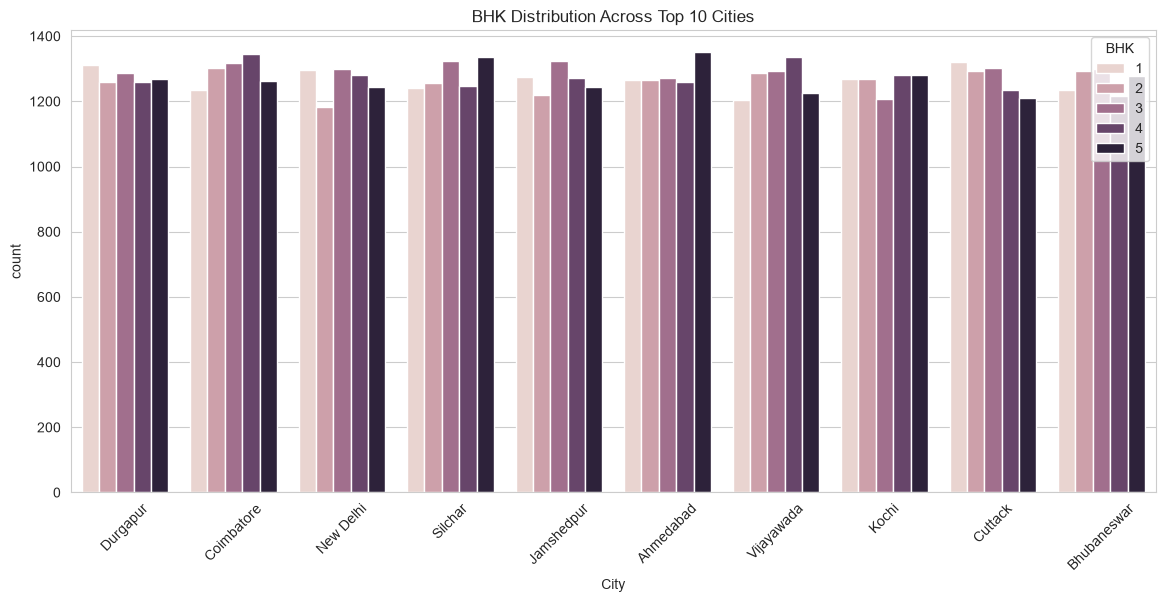

In [14]:
# 9. BHK distribution across cities (top 10 cities)
top_cities = df['City'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.countplot(data=df[df['City'].isin(top_cities)], x='City', hue='BHK')
plt.title("BHK Distribution Across Top 10 Cities")
plt.xticks(rotation=45)
plt.legend(title='BHK')
plt.show()

C:\Users\suppo\AppData\Local\Temp\ipykernel_14960\39494913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_expensive.values, y=top5_expensive.index, palette='rocket')


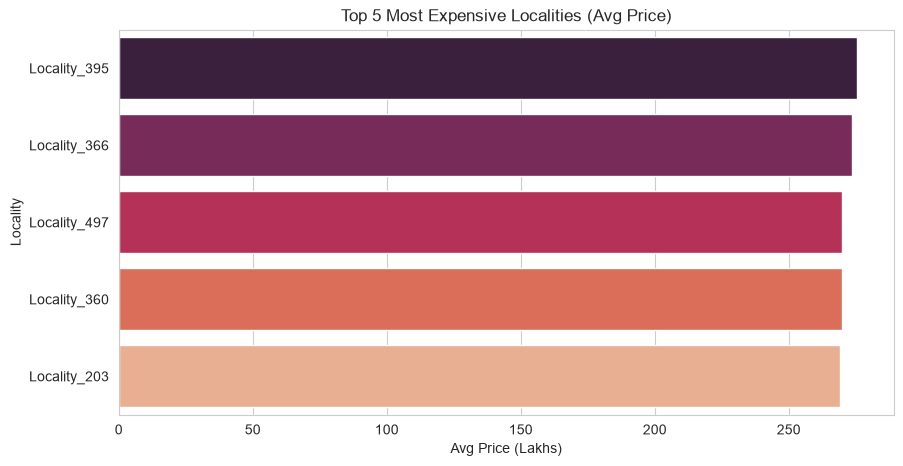

In [15]:
# 10. Price trends for top 5 most expensive localities
top5_expensive = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top5_expensive.values, y=top5_expensive.index, palette='rocket')
plt.title("Top 5 Most Expensive Localities (Avg Price)")
plt.xlabel("Avg Price (Lakhs)")
plt.show()

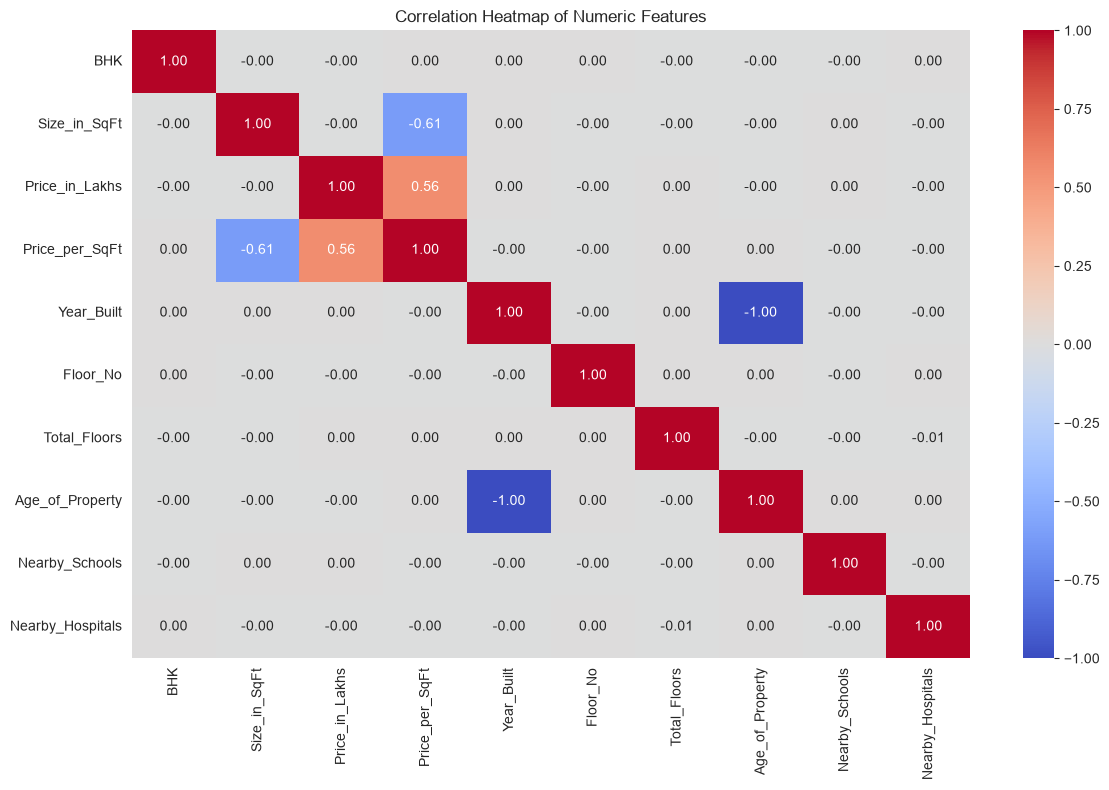

In [16]:
# 11. Correlation between numeric features
numeric_cols = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 
                 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property',
                 'Nearby_Schools', 'Nearby_Hospitals']

plt.figure(figsize=(12,8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

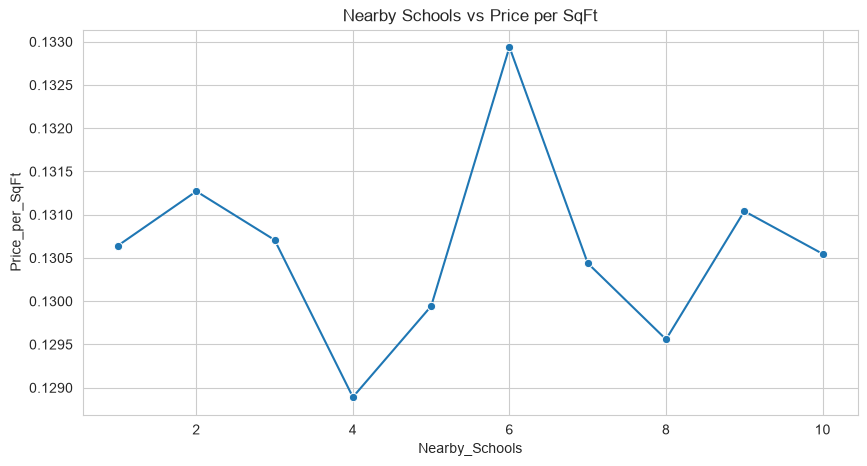

In [17]:
# 12. Nearby Schools vs Price per SqFt
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Nearby_Schools', y='Price_per_SqFt', marker='o', errorbar=None)
plt.title("Nearby Schools vs Price per SqFt")
plt.show()

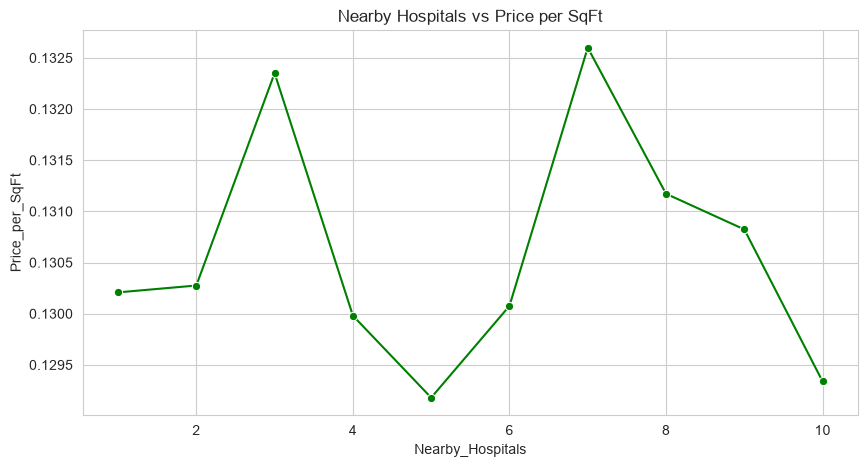

In [18]:
# 13. Nearby Hospitals vs Price per SqFt
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Nearby_Hospitals', y='Price_per_SqFt', marker='o', color='green', errorbar=None)
plt.title("Nearby Hospitals vs Price per SqFt")
plt.show()

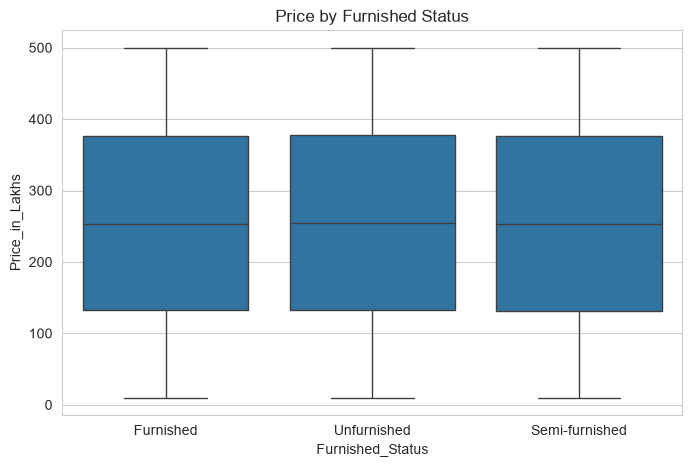

In [19]:
# 14. Price by Furnished Status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Furnished_Status', y='Price_in_Lakhs')
plt.title("Price by Furnished Status")
plt.show()

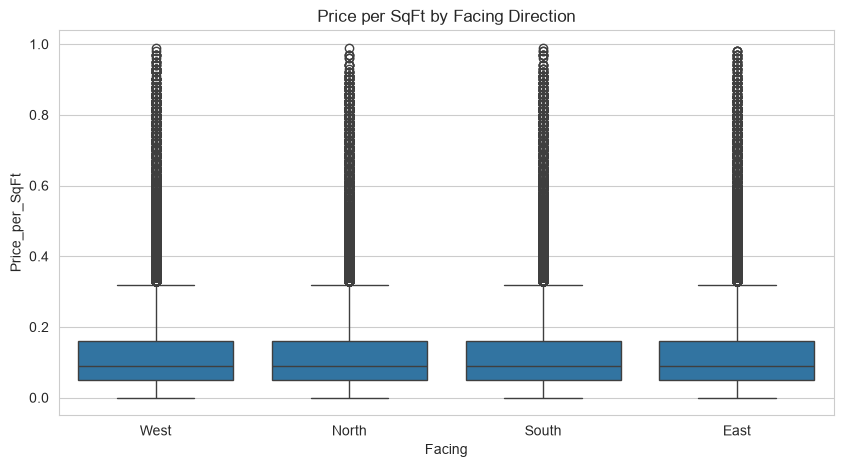

In [20]:
# 15. Price per SqFt by Facing direction
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Facing', y='Price_per_SqFt')
plt.title("Price per SqFt by Facing Direction")
plt.show()

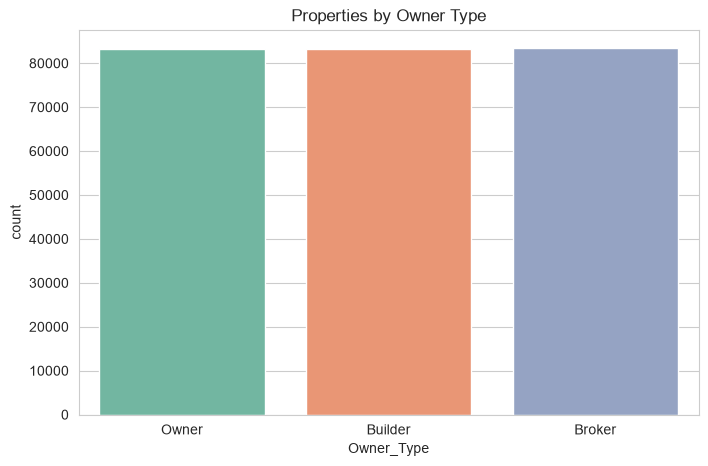

In [21]:
# 16. Properties by owner type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Owner_Type', hue='Owner_Type', palette='Set2', legend=False)
plt.title("Properties by Owner Type")
plt.show()

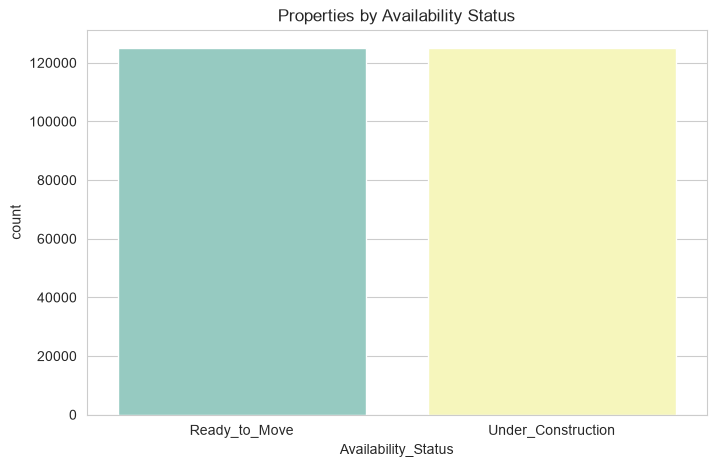

In [22]:
# 17. Properties by availability status
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Availability_Status', hue='Availability_Status', palette='Set3', legend=False)
plt.title("Properties by Availability Status")
plt.show()

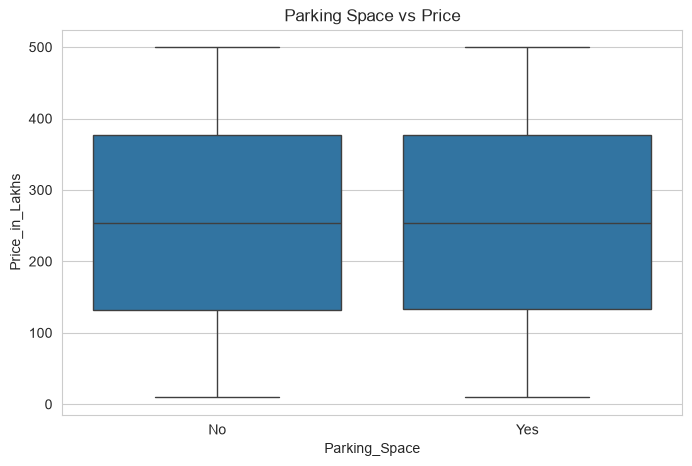

In [23]:
# 18. Does parking space affect price?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Parking_Space', y='Price_in_Lakhs')
plt.title("Parking Space vs Price")
plt.show()

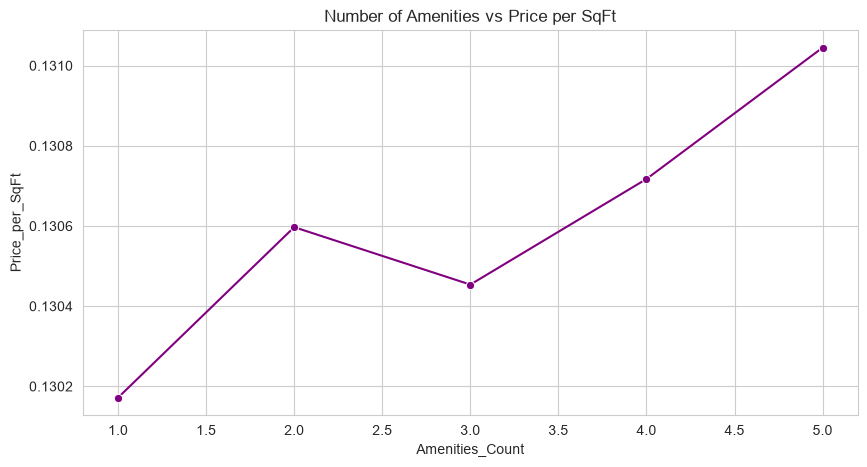

In [24]:
# 19. Amenities count vs Price per SqFt
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Amenities_Count', y='Price_per_SqFt', marker='o', color='purple', errorbar=None)
plt.title("Number of Amenities vs Price per SqFt")
plt.show()

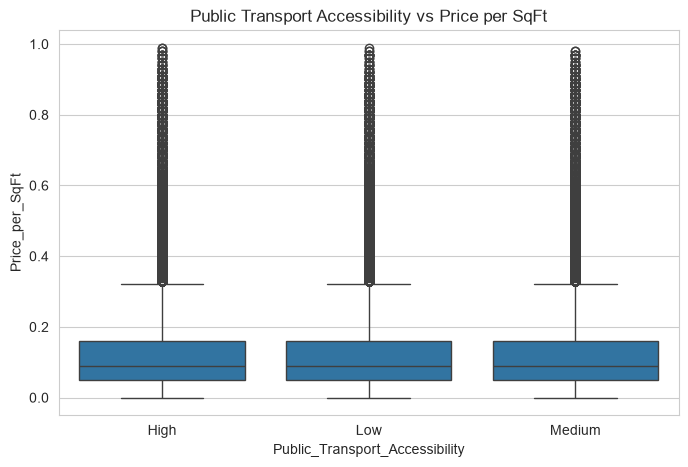

In [25]:
# 20. Public Transport Accessibility vs Price per SqFt
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Public_Transport_Accessibility', y='Price_per_SqFt')
plt.title("Public Transport Accessibility vs Price per SqFt")
plt.show()

In [26]:
# ---- 1. Price per Sqft already exists, but let's verify it's consistent ----
df['Price_per_SqFt_calc'] = (df['Price_in_Lakhs'] * 100000) / df['Size_in_SqFt']
# (Lakhs ko rupees mein convert karke sqft se divide kiya)

In [27]:
# ---- 2. Amenity Density Score (already counted Amenities_Count in EDA) ----
# agar pichle step mein nahi banaya, toh yahan bana lo:
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))

In [28]:
# ---- 3. Encode Security and Parking (Yes/No -> 1/0) ----
df['Security_encoded'] = df['Security'].map({'Yes': 1, 'No': 0})
df['Parking_encoded'] = df['Parking_Space'].map({'Yes': 1, 'No': 0})

In [29]:
# ---- 4. Encode Public Transport Accessibility (Low/Medium/High -> 0/1/2) ----
transport_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Transport_encoded'] = df['Public_Transport_Accessibility'].map(transport_map)

In [30]:
# ---- 5. Target 1: Future_Price_5Y (Regression target) ----
# Fixed growth rate approach (r=8% annually, t=5 years)
r = 0.08
t = 5
df['Future_Price_5Y'] = df['Price_in_Lakhs'] * ((1 + r) ** t)

In [31]:
# ---- 6. Target 2: Good_Investment (Classification target) ----
# Multi-factor score approach
median_price_per_sqft = df['Price_per_SqFt'].median()

df['Good_Investment'] = (
    (df['Price_per_SqFt'] <= median_price_per_sqft).astype(int) +
    (df['BHK'] >= 3).astype(int) +
    (df['Availability_Status'] == 'Ready_to_Move').astype(int) +
    (df['Security'] == 'Yes').astype(int) +
    (df['Amenities_Count'] >= 4).astype(int)
)

In [32]:
# Agar score >= 3 (out of 5 factors) toh Good Investment maana jaayega
df['Good_Investment'] = (df['Good_Investment'] >= 3).astype(int)

In [33]:
# Check distribution
print("Good_Investment distribution:")
print(df['Good_Investment'].value_counts())
print("\nPercentage:")
print(df['Good_Investment'].value_counts(normalize=True) * 100)

df[['Price_in_Lakhs', 'Future_Price_5Y', 'Good_Investment']].head(10)

Good_Investment distribution:
Good_Investment
1    126518
0    123482
Name: count, dtype: int64

Percentage:
Good_Investment
1    50.6072
0    49.3928
Name: proportion, dtype: float64


,Price_in_Lakhs,Future_Price_5Y,Good_Investment
0,489.76,719.618119,0
1,195.52,287.283026,1
2,183.79,270.047807,1
3,300.29,441.224528,1
4,182.90,268.740105,1
5,135.28,198.770702,1
6,318.12,467.422648,1
7,141.39,207.748297,1
8,189.16,277.938099,1
9,187.42,275.381468,0


In [34]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ---- Encode remaining categorical columns ----
cat_cols_to_encode = ['State', 'City', 'Property_Type', 'Furnished_Status', 
                       'Facing', 'Owner_Type']

le_dict = {}  # save encoders for later use in Streamlit app
for col in cat_cols_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    le_dict[col] = le

# ---- Select final features for modeling ----
feature_cols = [
    'BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 
    'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
    'Security_encoded', 'Parking_encoded', 'Transport_encoded', 'Amenities_Count',
    'State_encoded', 'City_encoded', 'Property_Type_encoded', 
    'Furnished_Status_encoded', 'Facing_encoded', 'Owner_Type_encoded'
]

X = df[feature_cols]
y_class = df['Good_Investment']         # Classification target
y_reg = df['Future_Price_5Y']           # Regression target

# ---- Train-test split (80-20) ----
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# ---- Feature Scaling ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFeatures used:", feature_cols)

Train shape: (200000, 19)
Test shape: (50000, 19)

Features used: ['BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Security_encoded', 'Parking_encoded', 'Transport_encoded', 'Amenities_Count', 'State_encoded', 'City_encoded', 'Property_Type_encoded', 'Furnished_Status_encoded', 'Facing_encoded', 'Owner_Type_encoded']


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ---- Define 5 classification models ----
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results_class = []

for name, model in classifiers.items():
    # Logistic Regression aur KNN scaled data pe better perform karte hain
    if name in ['Logistic Regression', 'KNN']:
        model.fit(X_train_scaled, y_class_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_class_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_class_test, y_pred)
    prec = precision_score(y_class_test, y_pred)
    rec = recall_score(y_class_test, y_pred)
    f1 = f1_score(y_class_test, y_pred)
    roc_auc = roc_auc_score(y_class_test, y_prob)
    
    results_class.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 
        'Recall': rec, 'F1_Score': f1, 'ROC_AUC': roc_auc
    })
    print(f"{name} done. Accuracy: {acc:.4f}")

results_class_df = pd.DataFrame(results_class).sort_values('Accuracy', ascending=False)
print("\n=== Classification Results ===")
print(results_class_df)

Logistic Regression done. Accuracy: 0.7915
Decision Tree done. Accuracy: 0.8073
Random Forest done. Accuracy: 0.8096
KNN done. Accuracy: 0.7646
XGBoost done. Accuracy: 0.8092

=== Classification Results ===
                 Model  Accuracy  Precision    Recall  F1_Score   ROC_AUC
2        Random Forest   0.80960   0.818560  0.801415  0.809897  0.927423
4              XGBoost   0.80920   0.810120  0.813705  0.811909  0.927731
1        Decision Tree   0.80734   0.810231  0.808726  0.809478  0.807323
0  Logistic Regression   0.79152   0.791308  0.798688  0.794981  0.879351
3                  KNN   0.76464   0.765891  0.770432  0.768155  0.837868


In [36]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ---- Define 5 regression models ----
regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

results_reg = []

for name, model in regressors.items():
    if name in ['Linear Regression', 'Ridge']:
        model.fit(X_train_scaled, y_reg_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_reg_train)
        y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae = mean_absolute_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    
    results_reg.append({
        'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2_Score': r2
    })
    print(f"{name} done. RMSE: {rmse:.2f}, R2: {r2:.4f}")

results_reg_df = pd.DataFrame(results_reg).sort_values('RMSE')
print("\n=== Regression Results ===")
print(results_reg_df)

Linear Regression done. RMSE: 207.46, R2: 0.0000
Ridge done. RMSE: 207.46, R2: 0.0000
Random Forest Regressor done. RMSE: 208.98, R2: -0.0147
Gradient Boosting done. RMSE: 207.48, R2: -0.0002
XGBoost Regressor done. RMSE: 209.06, R2: -0.0155

=== Regression Results ===
                     Model        RMSE         MAE  R2_Score
1                    Ridge  207.456815  179.718821  0.000022
0        Linear Regression  207.456815  179.718821  0.000022
3        Gradient Boosting  207.476039  179.724219 -0.000164
2  Random Forest Regressor  208.978776  180.533267 -0.014704
4        XGBoost Regressor  209.057925  180.632316 -0.015473


In [37]:
# ---- Rebuild feature set including Price_in_Lakhs ----
feature_cols_v2 = feature_cols + ['Price_in_Lakhs']

X_v2 = df[feature_cols_v2]

X_train2, X_test2, y_reg_train2, y_reg_test2 = train_test_split(
    X_v2, y_reg, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# ---- Retrain regression models ----
results_reg_v2 = []

for name, model in regressors.items():
    if name in ['Linear Regression', 'Ridge']:
        model.fit(X_train2_scaled, y_reg_train2)
        y_pred = model.predict(X_test2_scaled)
    else:
        model.fit(X_train2, y_reg_train2)
        y_pred = model.predict(X_test2)
    
    rmse = np.sqrt(mean_squared_error(y_reg_test2, y_pred))
    mae = mean_absolute_error(y_reg_test2, y_pred)
    r2 = r2_score(y_reg_test2, y_pred)
    
    results_reg_v2.append({
        'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2_Score': r2
    })
    print(f"{name} done. RMSE: {rmse:.2f}, R2: {r2:.4f}")

results_reg_df_v2 = pd.DataFrame(results_reg_v2).sort_values('RMSE')
print("\n=== Regression Results (v2 - with Price_in_Lakhs) ===")
print(results_reg_df_v2)

Linear Regression done. RMSE: 0.00, R2: 1.0000
Ridge done. RMSE: 0.00, R2: 1.0000
Random Forest Regressor done. RMSE: 0.00, R2: 1.0000
Gradient Boosting done. RMSE: 1.42, R2: 1.0000
XGBoost Regressor done. RMSE: 0.82, R2: 1.0000

=== Regression Results (v2 - with Price_in_Lakhs) ===
                     Model          RMSE           MAE  R2_Score
0        Linear Regression  2.892045e-13  2.272376e-13  1.000000
1                    Ridge  1.464024e-03  1.178296e-03  1.000000
2  Random Forest Regressor  3.260954e-03  2.038431e-03  1.000000
4        XGBoost Regressor  8.229642e-01  7.095599e-01  0.999984
3        Gradient Boosting  1.421080e+00  1.075058e+00  0.999953


In [38]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Set experiment name
mlflow.set_experiment("Real_Estate_Classification")

# ---- Log Classification Models ----
for name, model in classifiers.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_type", name)
        
        # Get metrics from results_class_df we calculated earlier
        row = results_class_df[results_class_df['Model'] == name].iloc[0]
        mlflow.log_metric("accuracy", row['Accuracy'])
        mlflow.log_metric("precision", row['Precision'])
        mlflow.log_metric("recall", row['Recall'])
        mlflow.log_metric("f1_score", row['F1_Score'])
        mlflow.log_metric("roc_auc", row['ROC_AUC'])
        
        if name == 'XGBoost':
            mlflow.xgboost.log_model(model, name="model")
        else:
            mlflow.sklearn.log_model(model, name="model")

print("Classification models logged to MLflow!")

Classification models logged to MLflow!


In [39]:
mlflow.set_experiment("Real_Estate_Regression")

# ---- Log Regression Models (v2 - with Price_in_Lakhs) ----
for name, model in regressors.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_type", name)
        
        row = results_reg_df_v2[results_reg_df_v2['Model'] == name].iloc[0]
        mlflow.log_metric("rmse", row['RMSE'])
        mlflow.log_metric("mae", row['MAE'])
        mlflow.log_metric("r2_score", row['R2_Score'])
        
        if name == 'XGBoost Regressor':
            mlflow.xgboost.log_model(model, name="model")
        else:
            mlflow.sklearn.log_model(model, name="model")

print("Regression models logged to MLflow!")

Regression models logged to MLflow!


In [40]:
import joblib
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# ---- Save best classification model (Random Forest) ----
best_classifier = classifiers['Random Forest']
joblib.dump(best_classifier, '../models/classification_model.pkl')

# ---- Save best regression model (Linear Regression) ----
best_regressor = regressors['Linear Regression']
joblib.dump(best_regressor, '../models/regression_model.pkl')

# ---- Save scalers ----
joblib.dump(scaler, '../models/scaler.pkl')       # for classification features
joblib.dump(scaler2, '../models/scaler2.pkl')     # for regression features (with Price_in_Lakhs)

# ---- Save label encoders (for categorical columns) ----
joblib.dump(le_dict, '../models/label_encoders.pkl')

# ---- Save feature column lists (order matters!) ----
joblib.dump(feature_cols, '../models/feature_cols_class.pkl')
joblib.dump(feature_cols_v2, '../models/feature_cols_reg.pkl')

print("All models and preprocessing objects saved successfully!")
print("\nFiles saved in 'models' folder:")
for f in os.listdir('../models'):
    print(f" - {f}")

All models and preprocessing objects saved successfully!

Files saved in 'models' folder:
 - classification_model.pkl
 - feature_cols_class.pkl
 - feature_cols_reg.pkl
 - label_encoders.pkl
 - regression_model.pkl
 - scaler.pkl
 - scaler2.pkl


In [41]:
import mlflow

# ---- Register best Classification model ----
mlflow.set_experiment("Real_Estate_Classification")

with mlflow.start_run(run_name="Random_Forest_Final"):
    mlflow.log_param("model_type", "Random Forest")
    row = results_class_df[results_class_df['Model'] == 'Random Forest'].iloc[0]
    mlflow.log_metric("accuracy", row['Accuracy'])
    mlflow.log_metric("roc_auc", row['ROC_AUC'])
    
    model_info = mlflow.sklearn.log_model(
        classifiers['Random Forest'], 
        name="model",
        registered_model_name="RealEstate_GoodInvestment_Classifier"
    )

# ---- Register best Regression model ----
mlflow.set_experiment("Real_Estate_Regression")

with mlflow.start_run(run_name="Linear_Regression_Final"):
    mlflow.log_param("model_type", "Linear Regression")
    row = results_reg_df_v2[results_reg_df_v2['Model'] == 'Linear Regression'].iloc[0]
    mlflow.log_metric("r2_score", row['R2_Score'])
    mlflow.log_metric("rmse", row['RMSE'])
    
    model_info2 = mlflow.sklearn.log_model(
        regressors['Linear Regression'], 
        name="model",
        registered_model_name="RealEstate_FuturePrice_Regressor"
    )

print("Both models registered successfully in MLflow Model Registry!")

Successfully registered model 'RealEstate_GoodInvestment_Classifier'.
Created version '1' of model 'RealEstate_GoodInvestment_Classifier'.
Successfully registered model 'RealEstate_FuturePrice_Regressor'.
Created version '1' of model 'RealEstate_FuturePrice_Regressor'.


Both models registered successfully in MLflow Model Registry!
